## Apartado 3. Búsqueda de hilos similares.

In [4]:
import zstandard as zstd
import json
import argparse
import io
import sys
from pathlib import Path
from datetime import datetime, UTC
import random
import os
import pandas as pd

Vamos a cargar el mismo modelo de fasttext que usamos en el apartado 2.

In [2]:
# !pip install fasttext
import fasttext
ft_model = fasttext.load_model('crawl-300d-2M-subword.bin')

In [11]:
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

rows = []
for subreddit in subreddits:
    filename = subreddit + '_final.json'

    if not os.path.exists(filename):
        print(f"No existe {filename}, se salta.")
        continue

    print(f"\nProcesando {filename}...")

    # Abrir JSON
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Aquí guardaremos los textos de un subreddit en concreto
    

    # Recorrer submissions
    for submission in data["submissions"]:

        # TEXTO DEL POST: juntamos título con texto del post
        texto_hilo = (submission.get("title", "") + " " + submission.get("selftext", "")).strip()

        # Añadimos ahora el texto de los comentarios del hilo
        for comment in submission.get("comments", []):
            body = comment.get("body", "").strip()

            # Guardamos el comentario si no está vacío
            if body:
                texto_hilo += body
                
        rows.append({
                    "subreddit": subreddit,
                    "texto": texto_hilo
                })
                

# Crear DataFrame
df = pd.DataFrame(rows)
df["texto"] = df["texto"].apply(lambda x: x.replace("\n", " "))


Procesando onepiece_final.json...

Procesando soccer_final.json...

Procesando gaming_final.json...

Procesando movies_final.json...

Procesando leagueoflegends_final.json...

Procesando drawing_final.json...


In [12]:
df["sentence_embeddings"] = df["texto"].apply(lambda x: ft_model.get_sentence_vector(x))
df.head()

,subreddit,texto,sentence_embeddings
0,onepiece,Official 🚨🚨🚨🚨🚨 Ace will be played by XOLODead ...,"[-0.0016739905, -0.012620177, 0.07350646, 0.00..."
1,onepiece,What is the symbol on dragon's face ? Is it a ...,"[-0.0012561227, -0.0059917225, 0.082547955, 0...."
2,onepiece,"What are exambles of ""bad devilfruits"" with go...","[-0.004081797, -0.017054116, 0.096680604, 0.01..."
3,onepiece,My Luffy live action cosplay Original sewed ve...,"[-0.0021282518, -0.025299337, 0.068572216, 0.0..."
4,onepiece,He's blonde??? Never expected for St Garling t...,"[-0.0048311288, -0.011010855, 0.086308576, 0.0..."


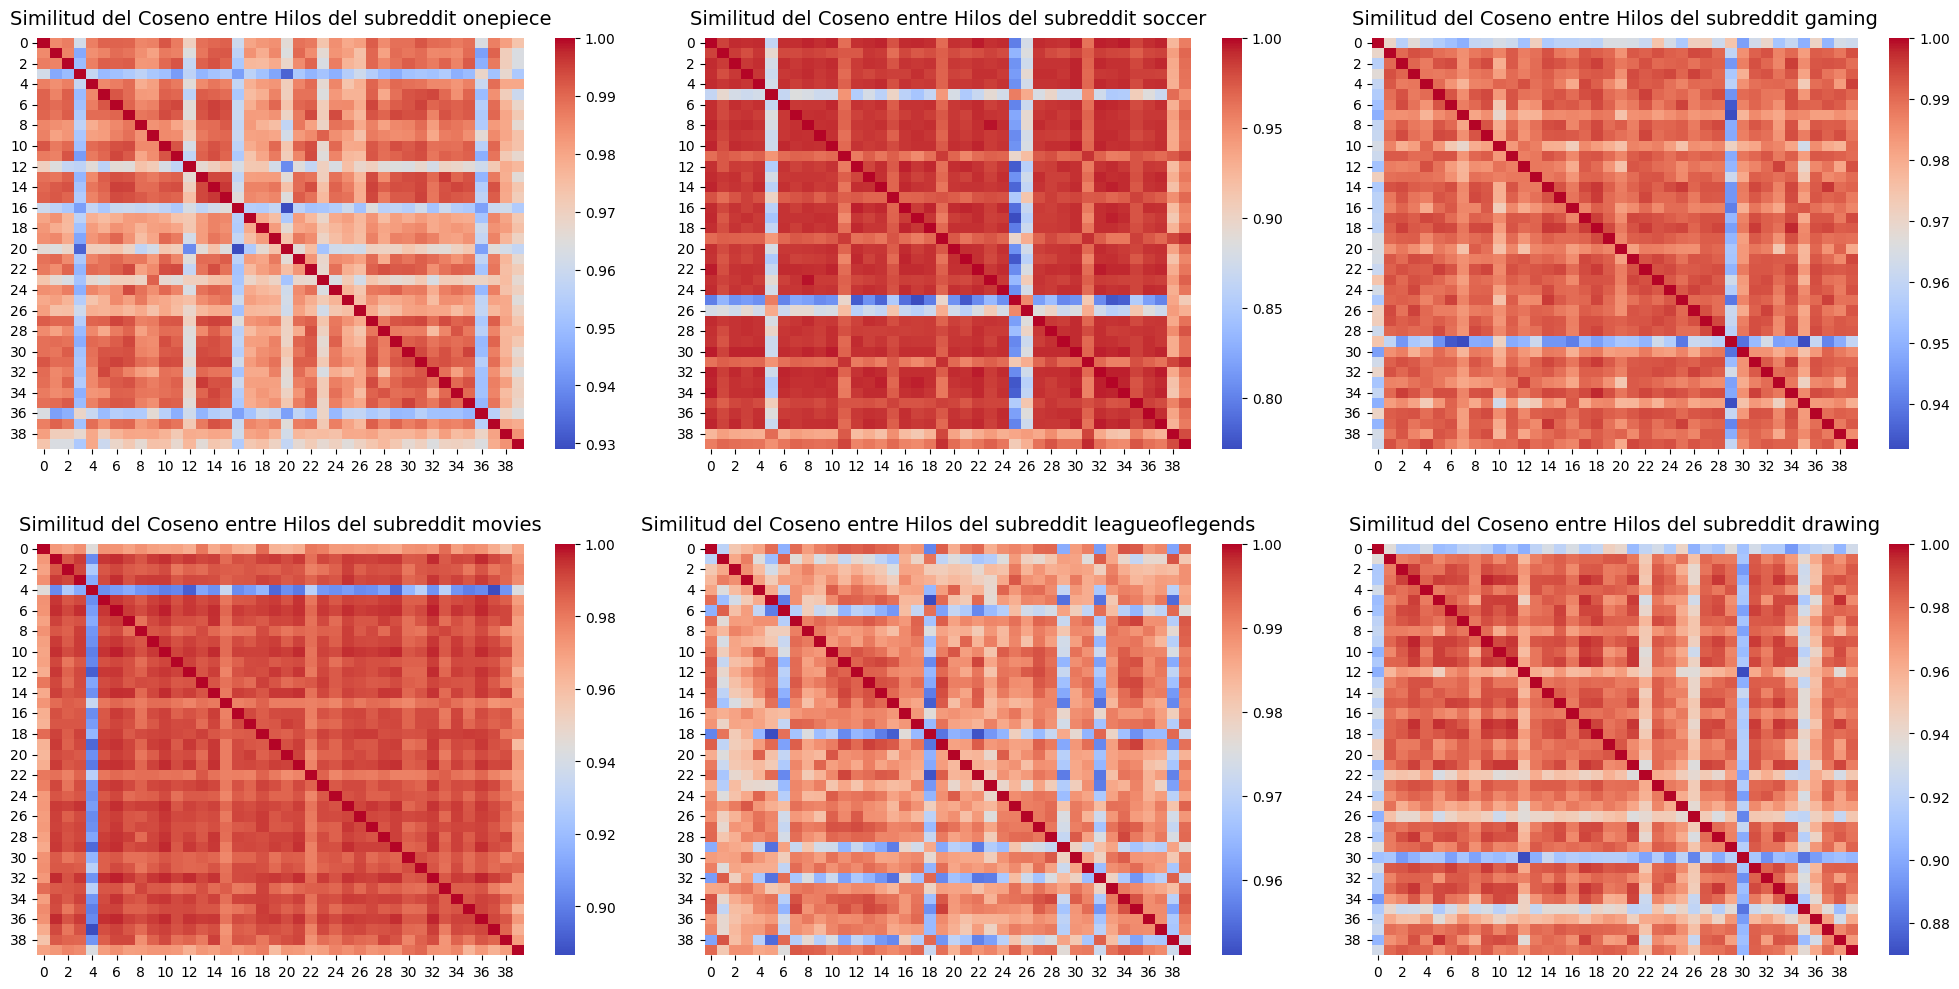

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df[df["subreddit"] == subreddit]
    # Para calcular la similaridad de los hilos, primero vamos a agrupar en una matriz de numpy todos los embeddings
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings'].values)
    # Con esta matriz, calculamos la similaridad entre los hilos
    matriz_similitud = cosine_similarity(matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True      
    )
    axes[i].set_title(f'Similitud del Coseno entre Hilos del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

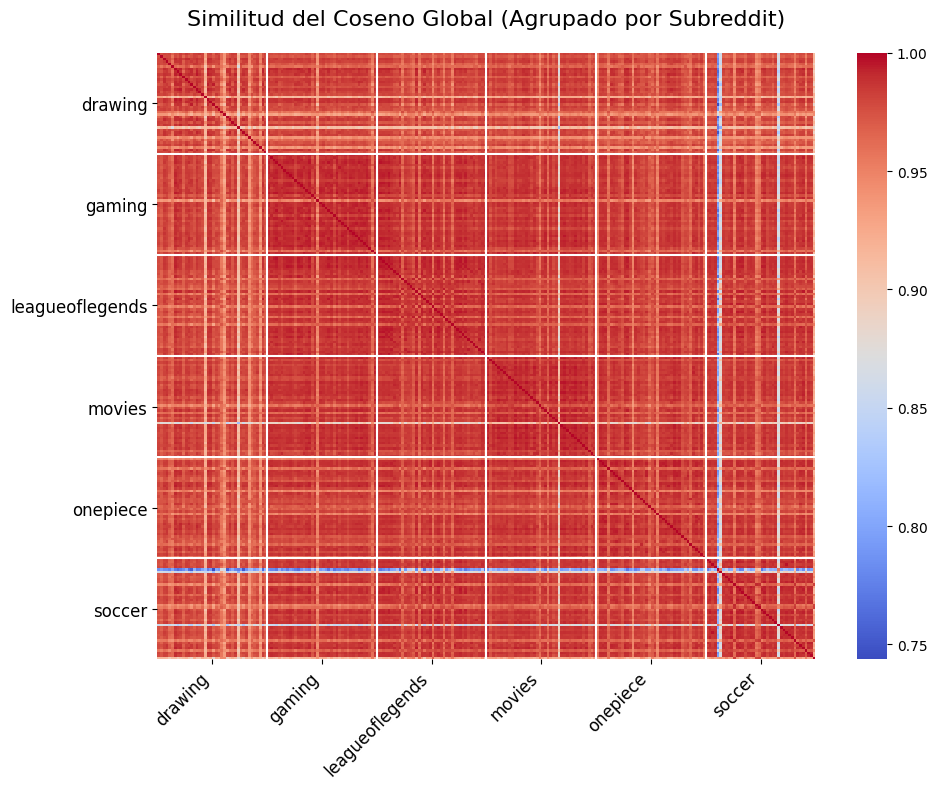

In [46]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = cosine_similarity(matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_unicos = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)

# ==========================================
# 4. Dibujar el Mapa de Calor
# ==========================================
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm',
    xticklabels=False, # Ocultamos los IDs individuales de los hilos
    yticklabels=False
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_unicos, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_unicos, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Analisis de resultados:

### Ahora vamos a realizar un pca para poder representar los sentence embeddings en un gráfico.

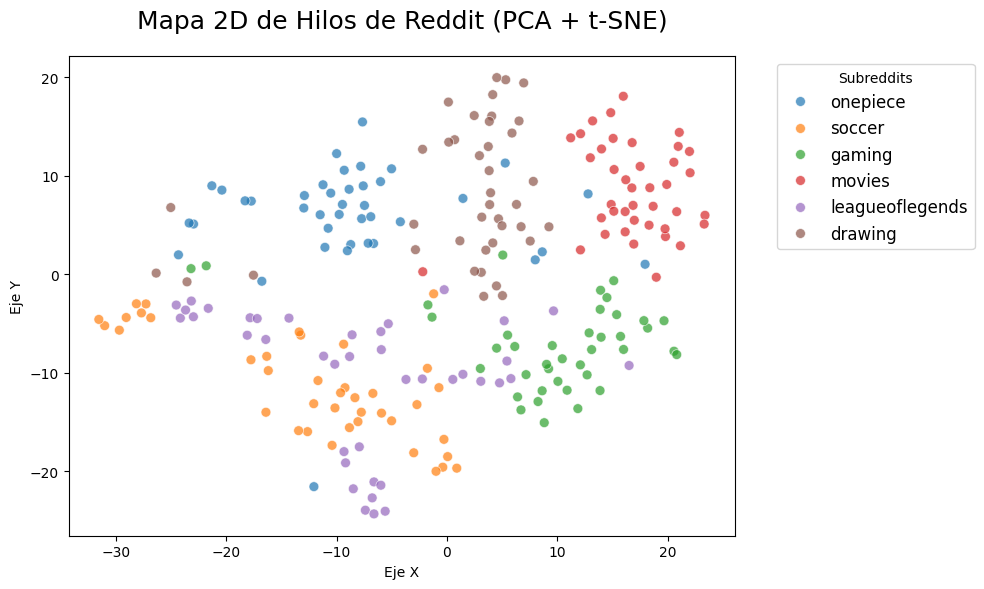

In [58]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

matriz_embeddings = np.vstack(df['sentence_embeddings'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()